# CodeAlpha Task 1 – Credit Scoring Model

This notebook builds and evaluates multiple classification models (**Logistic Regression**, **Decision Tree**, **Random Forest**) for predicting credit risk based on applicant demographic, financial, and credit history features.

**Note:** Every code cell contains line-by-line comments to explain each step during project presentation/viva.

## Cell 1 - Import Libraries

In [1]:
# Import pandas library for data manipulation, cleaning, and tabular data analysis
import pandas as pd

# Import numpy library for fast numerical computations and array operations
import numpy as np

# Import matplotlib.pyplot module for creating base plots and graphs
import matplotlib.pyplot as plt

# Import seaborn library for enhanced statistical data visualization (heatmaps, distributions)
import seaborn as sns

# Import train_test_split function to partition dataset into training and testing subsets
from sklearn.model_selection import train_test_split

# Import LabelEncoder to convert categorical string values into numerical integer representations
# Import StandardScaler to scale and normalize feature values to mean=0 and std=1
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Import Logistic Regression classifier algorithm for binary classification
from sklearn.linear_model import LogisticRegression

# Import Decision Tree classifier algorithm based on binary decision split trees
from sklearn.tree import DecisionTreeClassifier

# Import Random Forest classifier algorithm (ensemble method combining multiple decision trees)
from sklearn.ensemble import RandomForestClassifier

# Import evaluation metric functions from scikit-learn:
# - accuracy_score: calculates overall prediction accuracy
# - precision_score: calculates ratio of correctly predicted positive observations to total predicted positives
# - recall_score: calculates ratio of correctly predicted positive observations to all actual positives
# - f1_score: calculates harmonic mean of precision and recall
# - roc_auc_score: calculates Area Under the Receiver Operating Characteristic curve
# - confusion_matrix: computes matrix showing true positives, true negatives, false positives, false negatives
# - classification_report: generates text summary of precision, recall, and f1-score per class
# - roc_curve: computes false positive rates and true positive rates at different probability thresholds
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

# Import Python built-in warnings module to filter runtime warning notices
import warnings

# Suppress non-critical warnings to keep notebook output clean and legible
warnings.filterwarnings("ignore")

## Cell 2 - Load Dataset

In [2]:
# Read the CSV file 'credit_data.csv' into a Pandas DataFrame named df
df = pd.read_csv("credit_data.csv")

# Display the first 5 records of the dataset to inspect column structure and initial values
df.head()

,Age,Sex,Job,Housing,Saving_accounts,Checking_account,Credit_amount,Duration,Purpose,Credit_Status
0,57,male,highly_skilled,rent,little,little,4736,36,furniture/equipment,Bad
1,70,male,unskilled,own,little,moderate,1490,30,furniture/equipment,Bad
2,47,male,unskilled,own,little,moderate,2738,6,radio/TV,Good
3,33,female,skilled,own,little,moderate,938,48,radio/TV,Good
4,61,male,skilled,rent,moderate,rich,4314,36,furniture/equipment,Good


## Cell 3 - Dataset Information

In [3]:
# Print total number of rows and columns in the dataset (rows, columns)
print("Shape :", df.shape)

# Print dataset metadata overview (column names, data types, non-null counts)
df.info()

# Compute and display summary statistics (mean, std, min, 25%, 50%, 75%, max) for numeric columns
df.describe()

# Count and display the number of missing (null/NaN) values present in each column
df.isnull().sum()

Shape : (1000, 10)
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Age               1000 non-null   int64
 1   Sex               1000 non-null   str  
 2   Job               1000 non-null   str  
 3   Housing           1000 non-null   str  
 4   Saving_accounts   892 non-null    str  
 5   Checking_account  699 non-null    str  
 6   Credit_amount     1000 non-null   int64
 7   Duration          1000 non-null   int64
 8   Purpose           1000 non-null   str  
 9   Credit_Status     1000 non-null   str  
dtypes: int64(3), str(7)
memory usage: 78.3 KB


Age                   0
Sex                   0
Job                   0
Housing               0
Saving_accounts     108
Checking_account    301
Credit_amount         0
Duration              0
Purpose               0
Credit_Status         0
dtype: int64

## Cell 4 - Check Missing Values

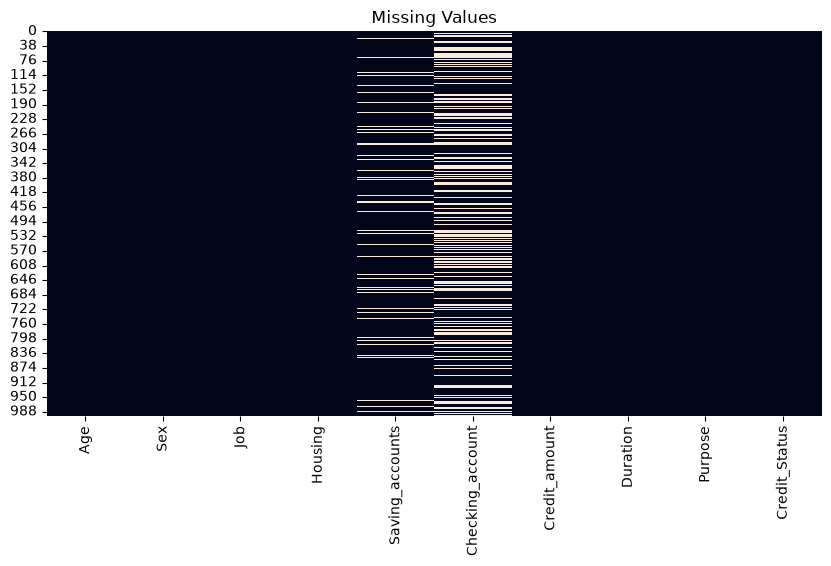

In [4]:
# Initialize a new plot figure with a width of 10 inches and height of 5 inches
plt.figure(figsize=(10,5))

# Generate a heatmap visualization highlighting missing values across all columns (cbar=False removes color bar)
sns.heatmap(df.isnull(), cbar=False)

# Set title for the missing values heatmap graph
plt.title("Missing Values")

# Display the figure window containing the heatmap
plt.show()

## Cell 5 - Feature Engineering

### Fill Missing Values & Encode Categorical Columns

In [5]:
from pandas.api.types import is_numeric_dtype
from sklearn.preprocessing import LabelEncoder

# Fill missing values: median for numeric columns, mode for categorical columns
for column in df.columns:
    if is_numeric_dtype(df[column]):
        df[column] = df[column].fillna(df[column].median())
    else:
        df[column] = df[column].fillna(df[column].mode()[0])

# Encode categorical columns to numeric integer values
encoder = LabelEncoder()

for column in df.columns:
    if not is_numeric_dtype(df[column]):
        df[column] = encoder.fit_transform(df[column].astype(str))


## Cell 6 - Correlation Heatmap

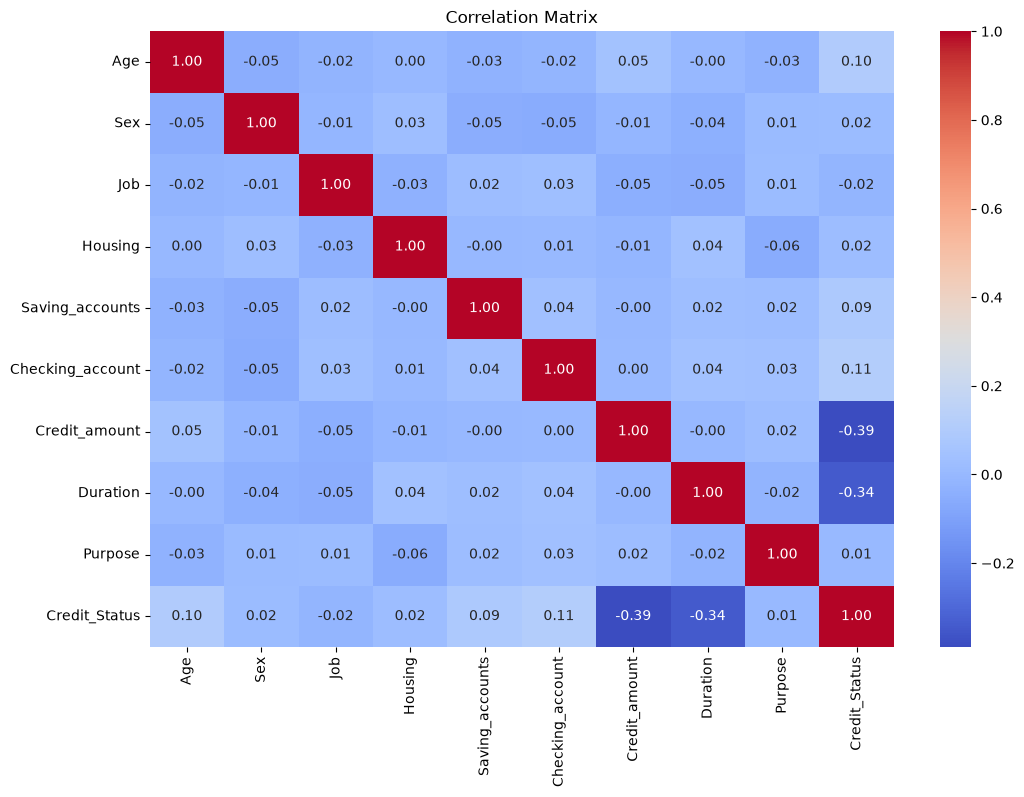

In [6]:
# Initialize figure size for correlation matrix (12 inches wide, 8 inches tall)
plt.figure(figsize=(12,8))

# Plot correlation heatmap using df.corr() to compute pairwise Pearson correlation values
# cmap='coolwarm' sets red-blue color map, annot=True displays values inside cells, fmt='.2f' formats to 2 decimal places
sns.heatmap(df.corr(), cmap="coolwarm", annot=True, fmt=".2f")

# Set title for the correlation matrix plot
plt.title("Correlation Matrix")

# Display the rendered correlation heatmap plot
plt.show()

## Cell 7 - Define Features and Target

In [7]:
# Define input features matrix X by dropping the target column 'Credit_Status' from DataFrame
X = df.drop("Credit_Status", axis=1)

# Define target label vector y containing only the 'Credit_Status' column values
y = df["Credit_Status"]

## Cell 8 - Train Test Split

In [8]:
# Split dataset into 80% training data and 20% test data
# X_train & y_train: used to fit/train models
# X_test & y_test: held out to evaluate model performance
# random_state=42 ensures exact reproducible split across executions
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Cell 9 - Feature Scaling

In [9]:
# Initialize StandardScaler object to scale numerical features to standard normal distribution (mean=0, variance=1)
scaler = StandardScaler()

# Calculate mean & std on X_train (fit) and transform X_train into scaled array values
X_train = scaler.fit_transform(X_train)

# Apply the exact same scaling parameters (mean & std learned from training data) to X_test
X_test = scaler.transform(X_test)

# Logistic Regression

## Cell 10

In [10]:
# Instantiate Logistic Regression model object
lr = LogisticRegression()

# Train the Logistic Regression model using training features (X_train) and training labels (y_train)
lr.fit(X_train, y_train)

# Predict discrete binary class predictions (0 or 1) for the unseen test features (X_test)
lr_pred = lr.predict(X_test)

# Predict continuous probability scores for positive class (class 1) for test set
lr_prob = lr.predict_proba(X_test)[:,1]

## Cell 11 - Evaluation

In [11]:
# Calculate and print Accuracy: total correct predictions / total predictions
print("Accuracy :", accuracy_score(y_test, lr_pred))

# Calculate and print Precision: true positives / (true positives + false positives)
print("Precision :", precision_score(y_test, lr_pred))

# Calculate and print Recall: true positives / (true positives + false negatives)
print("Recall :", recall_score(y_test, lr_pred))

# Calculate and print F1 Score: 2 * (Precision * Recall) / (Precision + Recall)
print("F1 Score :", f1_score(y_test, lr_pred))

# Calculate and print ROC-AUC score using predicted class probabilities
print("ROC AUC :", roc_auc_score(y_test, lr_prob))

# Print comprehensive text classification report with per-class precision, recall, and f1 metrics
print(classification_report(y_test, lr_pred))

Accuracy : 0.745
Precision : 0.6504854368932039
Recall : 0.8170731707317073
F1 Score : 0.7243243243243244
ROC AUC : 0.836606035551881
              precision    recall  f1-score   support

           0       0.85      0.69      0.76       118
           1       0.65      0.82      0.72        82

    accuracy                           0.74       200
   macro avg       0.75      0.76      0.74       200
weighted avg       0.77      0.74      0.75       200



# Decision Tree

## Cell 12

In [12]:
# Instantiate Decision Tree Classifier with random_state=42 for deterministic node splitting
dt = DecisionTreeClassifier(random_state=42)

# Train Decision Tree classifier using training features and target labels
dt.fit(X_train, y_train)

# Predict binary target labels (0 or 1) for testing dataset
dt_pred = dt.predict(X_test)

# Predict probability values for positive target class (class 1) on testing dataset
dt_prob = dt.predict_proba(X_test)[:,1]

## Cell 13

In [13]:
# Calculate and print overall Accuracy metric for Decision Tree
print("Accuracy :", accuracy_score(y_test, dt_pred))

# Calculate and print Precision metric for Decision Tree
print("Precision :", precision_score(y_test, dt_pred))

# Calculate and print Recall metric for Decision Tree
print("Recall :", recall_score(y_test, dt_pred))

# Calculate and print F1 Score metric for Decision Tree
print("F1 Score :", f1_score(y_test, dt_pred))

# Calculate and print Area Under ROC Curve (ROC-AUC) score for Decision Tree
print("ROC AUC :", roc_auc_score(y_test, dt_prob))

# Print detailed classification report showing precision, recall, and f1 for each target class
print(classification_report(y_test, dt_pred))

Accuracy : 0.645
Precision : 0.5555555555555556
Recall : 0.6707317073170732
F1 Score : 0.6077348066298343
ROC AUC : 0.648925175692435
              precision    recall  f1-score   support

           0       0.73      0.63      0.68       118
           1       0.56      0.67      0.61        82

    accuracy                           0.65       200
   macro avg       0.64      0.65      0.64       200
weighted avg       0.66      0.65      0.65       200



# Random Forest

## Cell 14

In [14]:
# Instantiate Random Forest Classifier ensemble model with 100 trees and fixed random seed
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Fit/train all 100 decision trees in the Random Forest model on training dataset
rf.fit(X_train, y_train)

# Predict target class labels using majority voting across all 100 decision trees
rf_pred = rf.predict(X_test)

# Compute average positive class probability across all 100 decision trees
rf_prob = rf.predict_proba(X_test)[:,1]

## Cell 15

In [15]:
# Calculate and print Accuracy metric for Random Forest classifier
print("Accuracy :", accuracy_score(y_test, rf_pred))

# Calculate and print Precision metric for Random Forest classifier
print("Precision :", precision_score(y_test, rf_pred))

# Calculate and print Recall metric for Random Forest classifier
print("Recall :", recall_score(y_test, rf_pred))

# Calculate and print F1 Score metric for Random Forest classifier
print("F1 Score :", f1_score(y_test, rf_pred))

# Calculate and print ROC-AUC metric for Random Forest classifier
print("ROC AUC :", roc_auc_score(y_test, rf_prob))

# Print full classification report summary for Random Forest classifier
print(classification_report(y_test, rf_pred))

Accuracy : 0.675
Precision : 0.5858585858585859
Recall : 0.7073170731707317
F1 Score : 0.6408839779005525
ROC AUC : 0.7753203803224472
              precision    recall  f1-score   support

           0       0.76      0.65      0.70       118
           1       0.59      0.71      0.64        82

    accuracy                           0.68       200
   macro avg       0.67      0.68      0.67       200
weighted avg       0.69      0.68      0.68       200



# Confusion Matrix

## Cell 16

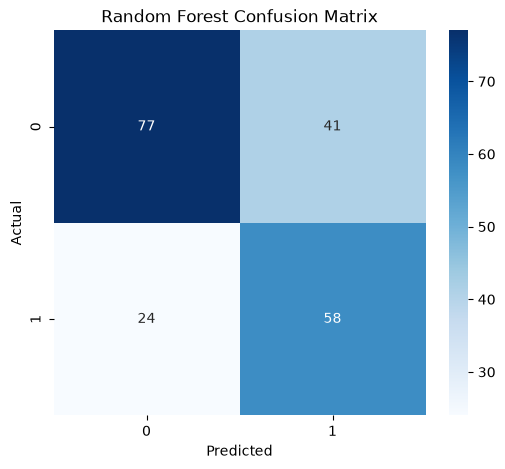

In [16]:
# Compute confusion matrix matrix comparing actual ground truth labels vs Random Forest predictions
cm = confusion_matrix(y_test, rf_pred)

# Initialize figure canvas with width 6 inches and height 5 inches
plt.figure(figsize=(6,5))

# Render confusion matrix heatmap (annot=True displays counts, fmt='d' formats counts as integers, cmap='Blues' sets color scheme)
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")

# Label X-axis as 'Predicted' class
plt.xlabel("Predicted")

# Label Y-axis as 'Actual' class
plt.ylabel("Actual")

# Set descriptive title for the confusion matrix chart
plt.title("Random Forest Confusion Matrix")

# Render heatmap plot on screen
plt.show()

# ROC Curve

## Cell 17

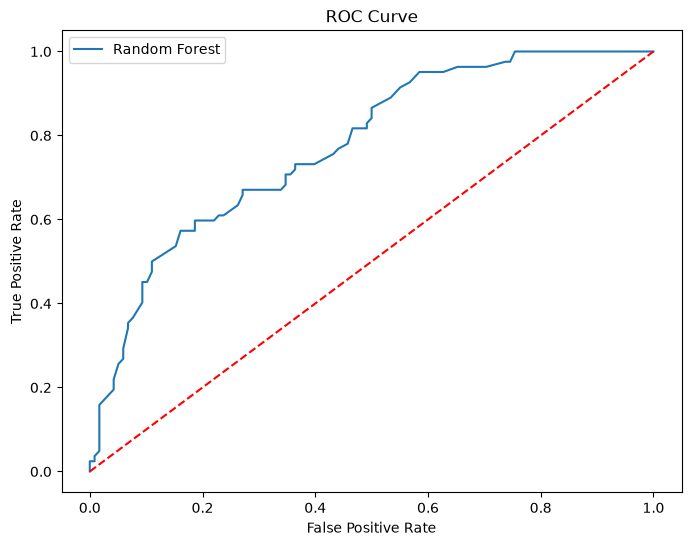

In [17]:
# Calculate False Positive Rates (fpr) and True Positive Rates (tpr) at varying decision thresholds
fpr, tpr, _ = roc_curve(y_test, rf_prob)

# Initialize figure canvas with 8 inches width and 6 inches height
plt.figure(figsize=(8,6))

# Plot True Positive Rate against False Positive Rate for Random Forest model
plt.plot(fpr, tpr, label="Random Forest")

# Plot baseline reference line representing random chance classifier (diagonal dashed red line)
plt.plot([0,1],[0,1],'r--')

# Set X-axis label to 'False Positive Rate'
plt.xlabel("False Positive Rate")

# Set Y-axis label to 'True Positive Rate'
plt.ylabel("True Positive Rate")

# Set chart title for ROC plot
plt.title("ROC Curve")

# Display plot legend for model curve identification
plt.legend()

# Render and display ROC curve graph
plt.show()

# Compare Models

## Cell 18

In [18]:
# Create a summary Pandas DataFrame collecting performance metrics across all three classifiers
results = pd.DataFrame({
    # List of model names
    "Model":["Logistic Regression","Decision Tree","Random Forest"],
    # List of accuracy scores calculated for each model
    "Accuracy":[
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ],
    # List of precision scores calculated for each model
    "Precision":[
        precision_score(y_test, lr_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred)
    ],
    # List of recall scores calculated for each model
    "Recall":[
        recall_score(y_test, lr_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred)
    ],
    # List of F1 scores calculated for each model
    "F1 Score":[
        f1_score(y_test, lr_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred)
    ],
    # List of ROC-AUC scores calculated for each model using probability predictions
    "ROC AUC":[
        roc_auc_score(y_test, lr_prob),
        roc_auc_score(y_test, dt_prob),
        roc_auc_score(y_test, rf_prob)
    ]
})

# Display the model performance comparative DataFrame table
results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.745,0.650485,0.817073,0.724324,0.836606
1,Decision Tree,0.645,0.555556,0.670732,0.607735,0.648925
2,Random Forest,0.675,0.585859,0.707317,0.640884,0.775320


# Best Model

## Cell 19

In [19]:
# Sort model performance DataFrame by Accuracy metric in descending order (highest accuracy first)
best_model = results.sort_values(by="Accuracy", ascending=False)

# Display the sorted results table showing top-performing model at the top
best_model

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.745,0.650485,0.817073,0.724324,0.836606
2,Random Forest,0.675,0.585859,0.707317,0.640884,0.775320
1,Decision Tree,0.645,0.555556,0.670732,0.607735,0.648925


# Feature Importance

## Cell 20

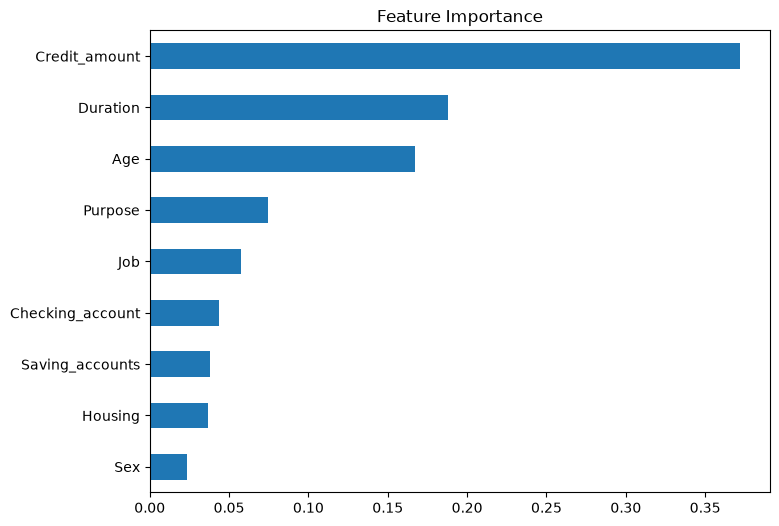

In [20]:
# Extract relative feature importance weights calculated by Random Forest model and map to column names
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

# Sort feature importances in ascending order and create horizontal bar chart (kind='barh')
importance.sort_values().plot(
    kind="barh",
    figsize=(8,6)
)

# Set chart title for feature importance bar chart
plt.title("Feature Importance")

# Display feature importance horizontal bar plot
plt.show()